<a href="https://colab.research.google.com/github/AdnanAnwarR/practice_DS/blob/main/Assignment_Day_12_Adnan_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning
### Tolong baca perintah dan tagar komen dengan saksama :)

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# A. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [37]:
# untuk plot Q-Q
import scipy.stats as stats

Load Dataset

In [38]:
df_california = pd.read_csv('california_dataset.csv')
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Split Data

In [39]:
from sklearn.model_selection import train_test_split
df_california_train, df_california_test = train_test_split(df_california, test_size=0.2, random_state=42)

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
3. Lakukan untuk tujuan machine learning dan juga exploratory data analysis.

Untuk tujuan Machine Learning

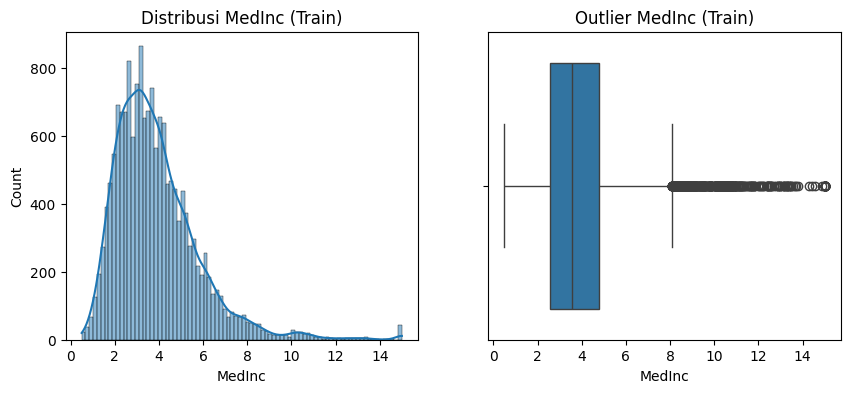

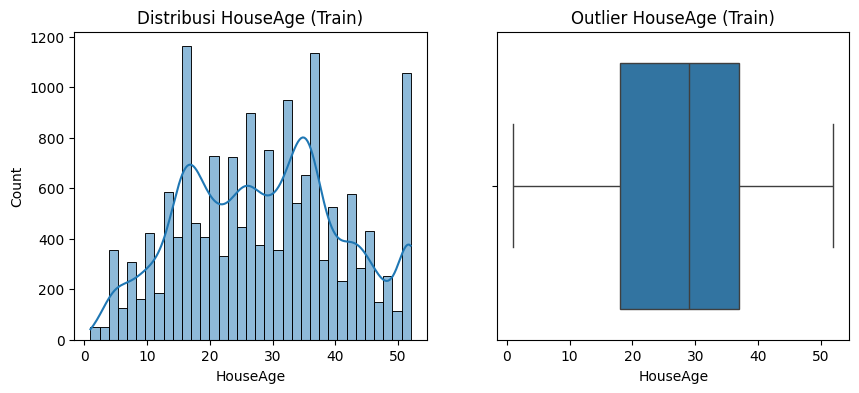

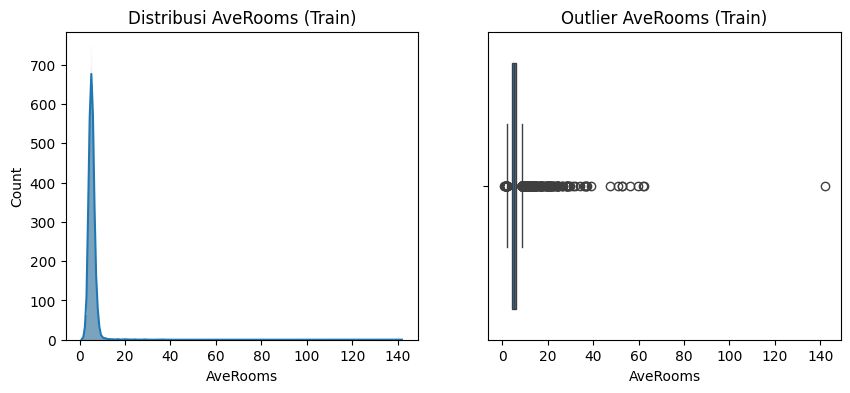

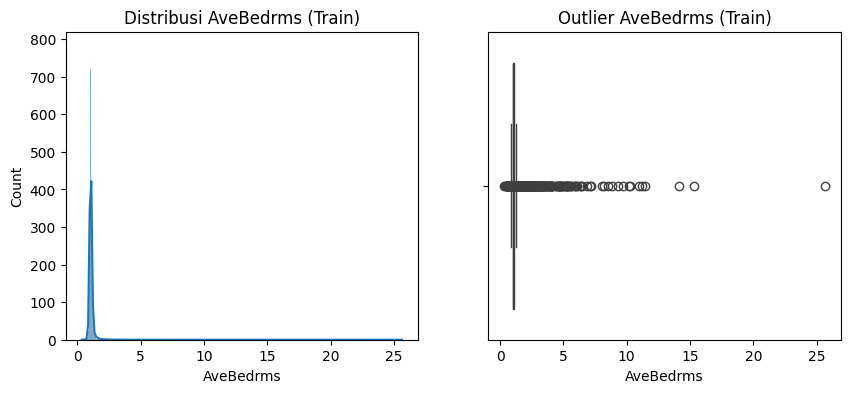

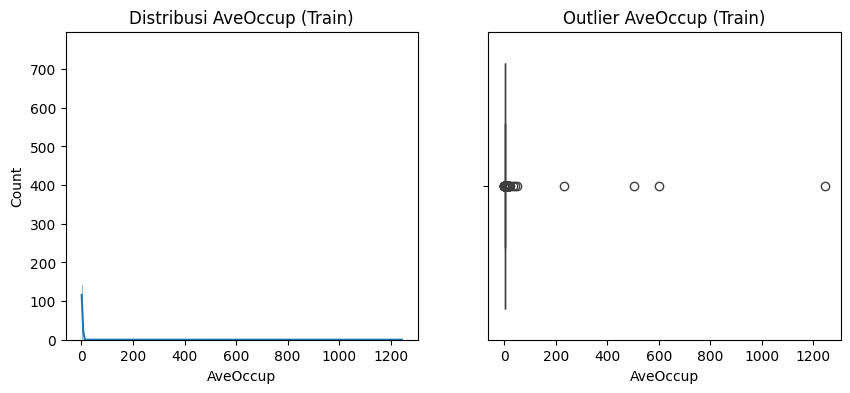

In [40]:
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
for col in kolom_kolom:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df_california_train[col], kde=True)
    plt.title(f'Distribusi {col} (Train)')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_california_train[col])
    plt.title(f'Outlier {col} (Train)')
    plt.show()

Untuk tujuan Exploratory Data Analysis

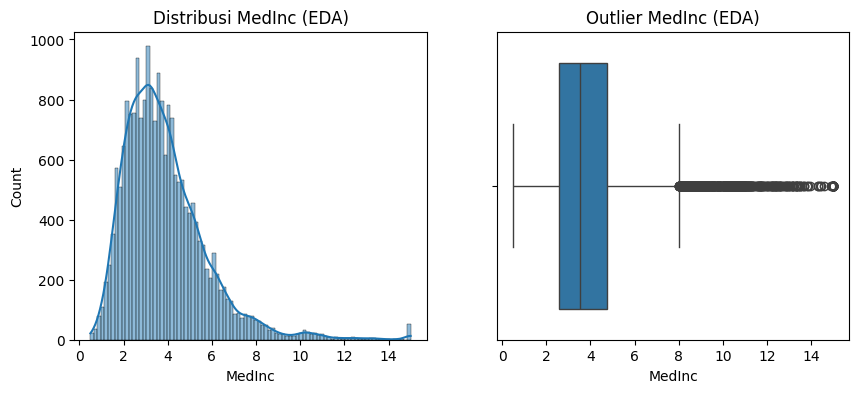

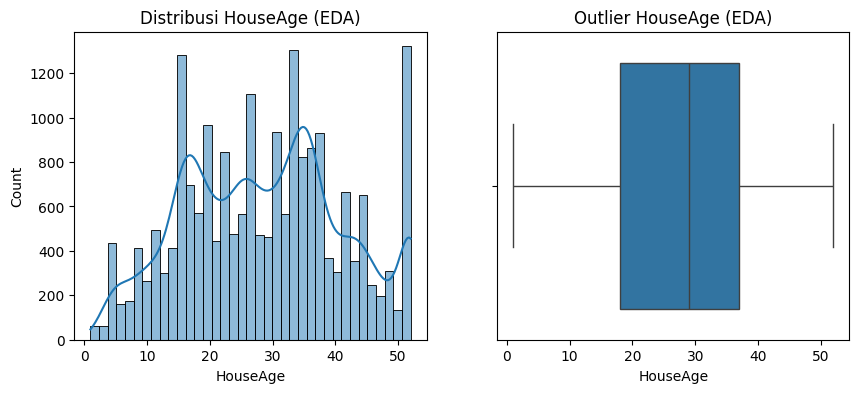

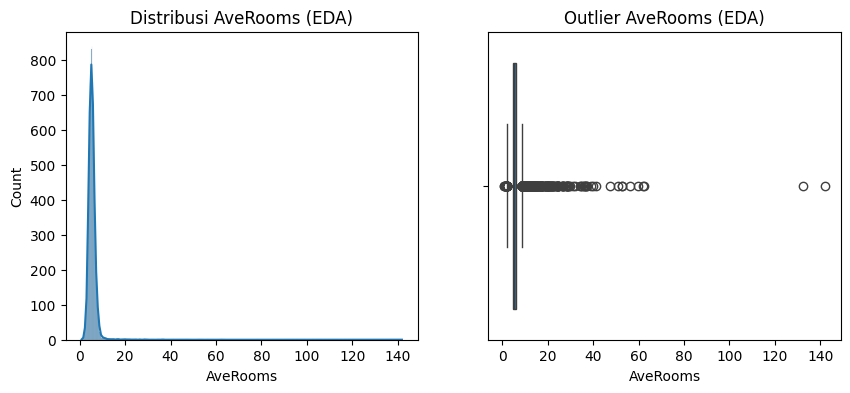

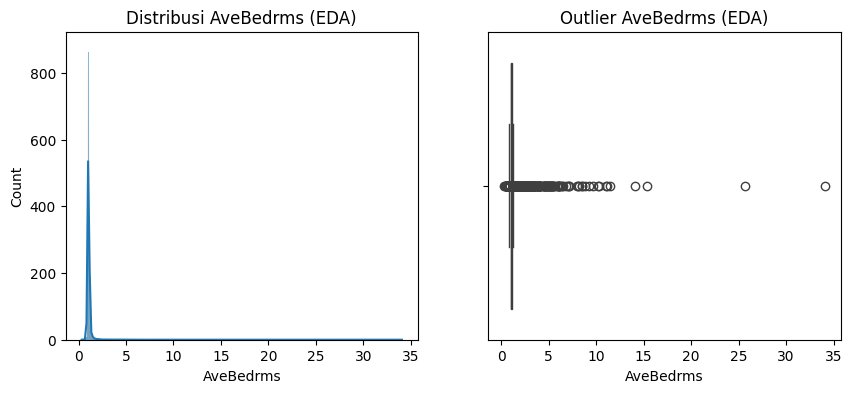

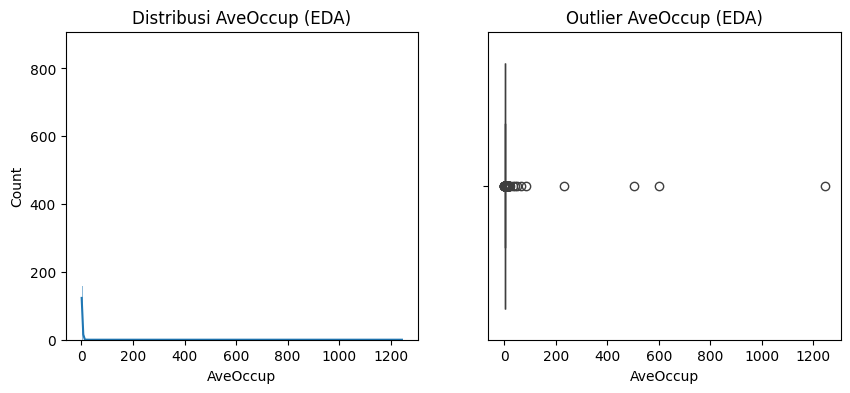

In [41]:
for col in kolom_kolom:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df_california[col], kde=True)
    plt.title(f'Distribusi {col} (EDA)')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_california[col])
    plt.title(f'Outlier {col} (EDA)')
    plt.show()

**TULISKAN INSIGHT DI SINI**

Insight: Terdapat outliers yang signifikan pada kolom AveRooms, AveBedrms, dan AveOccup baik di data training maupun dataset utuh. Distribusinya juga cenderung right-skewed. MedInc memiliki distribusi yang agak right-skewed dengan beberapa outliers, sementara HouseAge memiliki distribusi yang lebih merata (cenderung bimodal) dan tidak memiliki outlier yang terlihat pada boxplot.

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali untuk tujuan machine learning dan juga exploratory data analysis.

Melakukan outlier handling menggunakan IQR

In [42]:
# Kolom yang dipilih: MedInc
Q1 = df_california_train['MedInc'].quantile(0.25)
Q3 = df_california_train['MedInc'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Untuk ML (Handling pada data train)
df_california_train_handled = df_california_train.copy()
df_california_train_handled = df_california_train_handled[(df_california_train_handled['MedInc'] >= lower_bound) & (df_california_train_handled['MedInc'] <= upper_bound)]

# Untuk EDA (Handling pada seluruh data)
Q1_eda = df_california['MedInc'].quantile(0.25)
Q3_eda = df_california['MedInc'].quantile(0.75)
IQR_eda = Q3_eda - Q1_eda
lower_bound_eda = Q1_eda - 1.5 * IQR_eda
upper_bound_eda = Q3_eda + 1.5 * IQR_eda

df_california_handled = df_california.copy()
df_california_handled = df_california_handled[(df_california_handled['MedInc'] >= lower_bound_eda) & (df_california_handled['MedInc'] <= upper_bound_eda)]

Menampilkan distribusi setiap kolom untuk tujuan Machine Learning

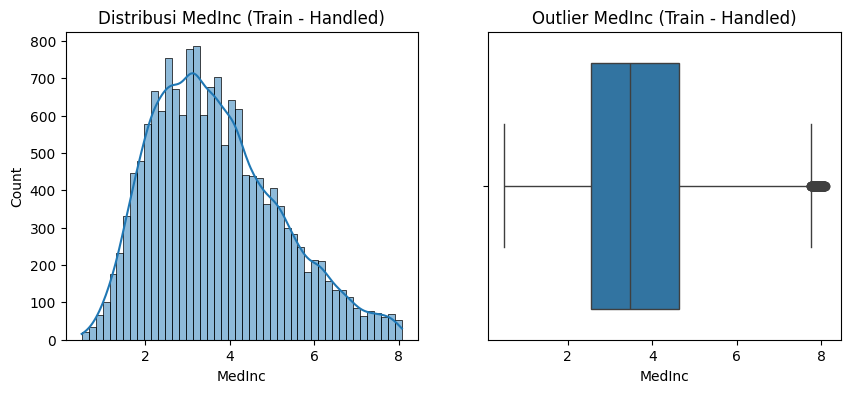

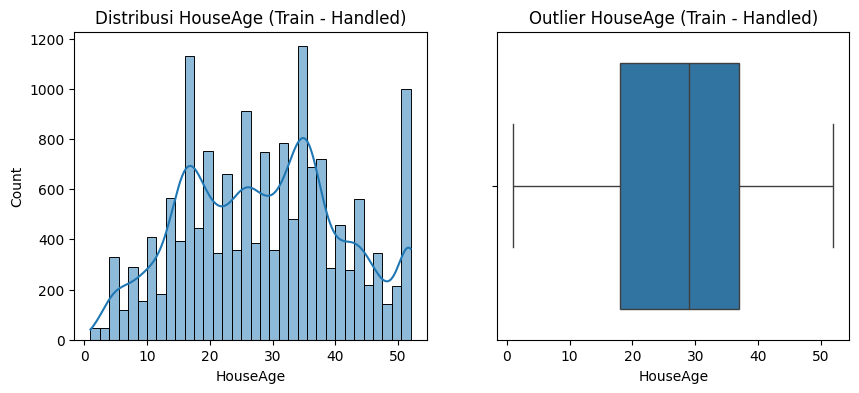

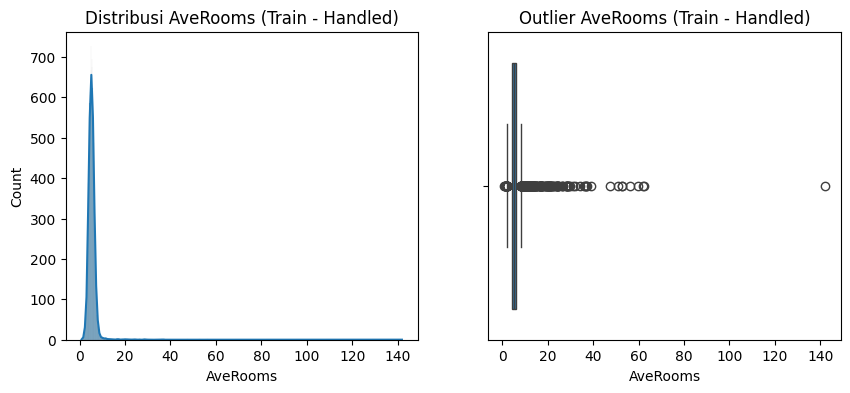

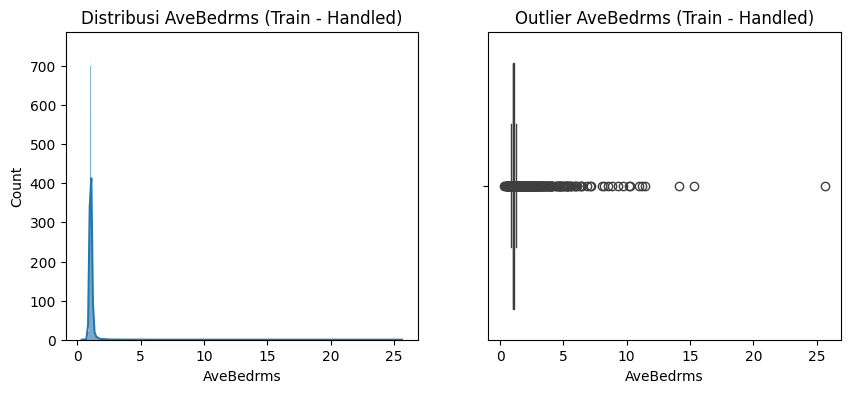

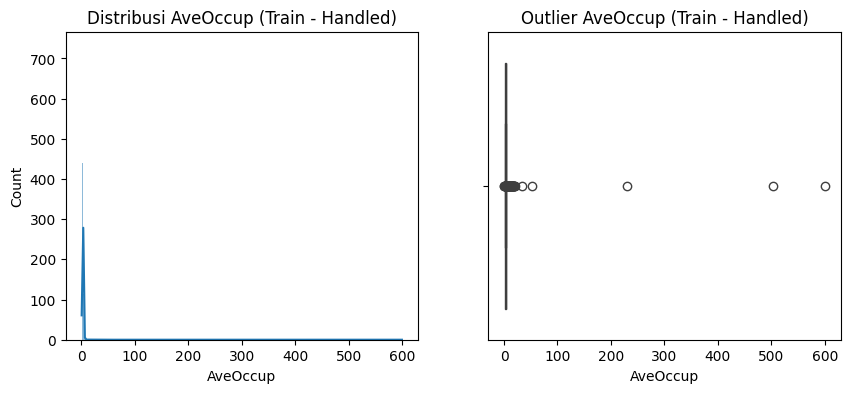

In [43]:
for col in kolom_kolom:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df_california_train_handled[col], kde=True)
    plt.title(f'Distribusi {col} (Train - Handled)')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_california_train_handled[col])
    plt.title(f'Outlier {col} (Train - Handled)')
    plt.show()

Menampilkan distribusi setiap kolom untuk tujuan Exploratory Data Analysis

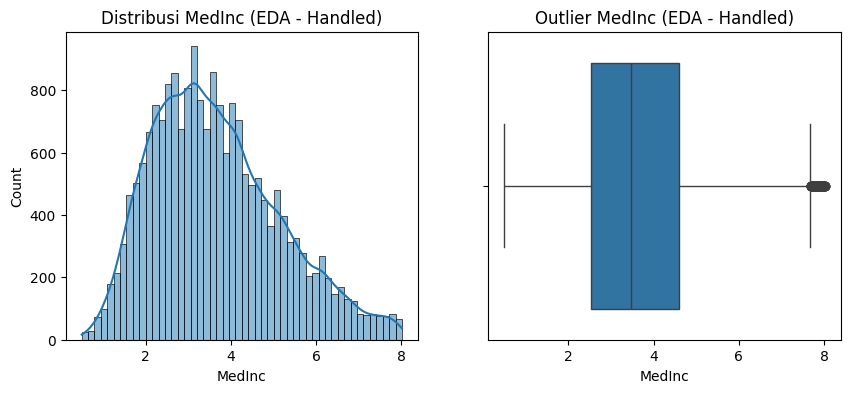

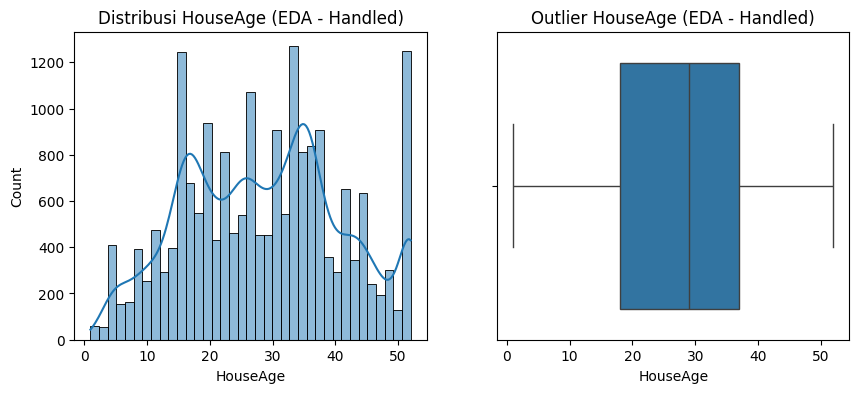

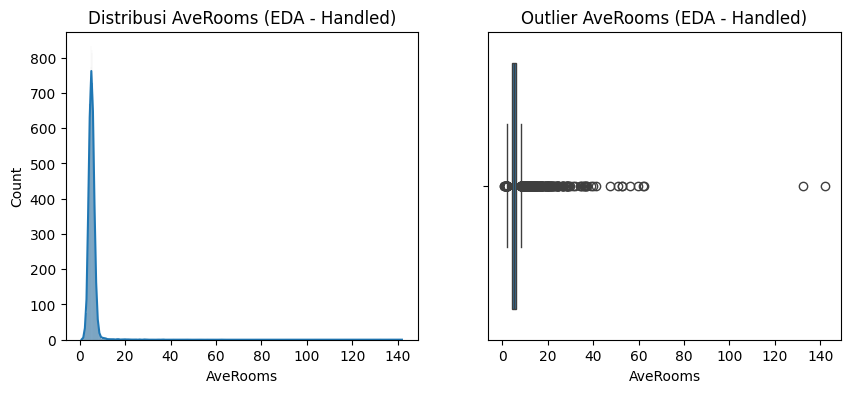

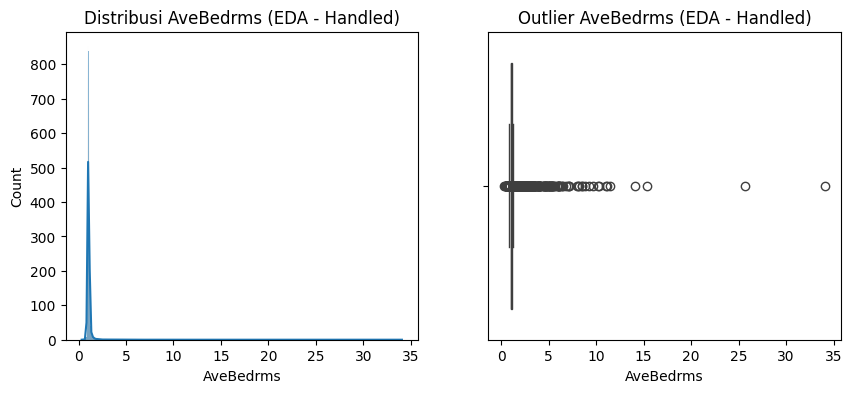

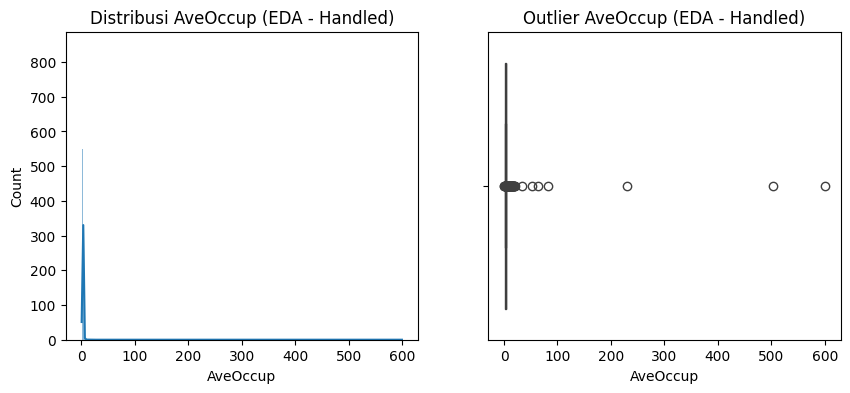

In [44]:
for col in kolom_kolom:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df_california_handled[col], kde=True)
    plt.title(f'Distribusi {col} (EDA - Handled)')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_california_handled[col])
    plt.title(f'Outlier {col} (EDA - Handled)')
    plt.show()

In [45]:
#tambahkan cell jika diperlukan

**TULISKAN INSIGHT DI SINI**

Insight: Setelah dilakukan handling outlier menggunakan IQR pada kolom MedInc, outlier pada kolom tersebut berhasil dihilangkan. Bentuk distribusi MedInc menjadi lebih mendekati normal dan tidak terlalu right-skewed dibandingkan sebelumnya. Handling outlier tidak memengaruhi distribusi kolom lain yang tidak dihandle.

# B. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [46]:
df_company = pd.read_csv('company.csv')
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,NaN,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

Split Data

In [47]:
from sklearn.model_selection import train_test_split
# lakukan splitting data terlebih dahulu ke dalam data train dan data test
df_company_train, df_company_test = train_test_split(df_company, test_size=0.2, random_state=42)
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value hanya pada kolom Headquarters di company.csv, Cek jenis missing valuenya apakah ada atau tidak ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?
4. Lakukan untuk tujuan machine learning dan juga exploratory data analysis.

Untuk tujuan Machine Learning

In [48]:
missing_percentage_train = df_company_train['Headquarters'].isnull().mean() * 100
print(f"Persentase Missing Value Headquarters (Train): {missing_percentage_train:.2f}%")
print(f"Tipe data Headquarters: {df_company_train['Headquarters'].dtype}")

if missing_percentage_train > 20:
    print("Kolom di-drop karena missing value > 20%")
    df_company_train = df_company_train.drop('Headquarters', axis=1)
else:
    print("Kolom tidak di-drop, dilakukan imputasi.")
    mode_value = df_company_train['Headquarters'].mode()[0]
    df_company_train['Headquarters'] = df_company_train['Headquarters'].fillna(mode_value)
    print(f"Missing value diisi dengan modus: {mode_value}")

Persentase Missing Value Headquarters (Train): 0.00%
Tipe data Headquarters: object
Kolom tidak di-drop, dilakukan imputasi.
Missing value diisi dengan modus: New York, NY


Untuk tujuan Exploratory Data Analysis

In [49]:
missing_percentage = df_company['Headquarters'].isnull().mean() * 100
print(f"Persentase Missing Value Headquarters (EDA): {missing_percentage:.2f}%")
print(f"Tipe data Headquarters: {df_company['Headquarters'].dtype}")

if missing_percentage > 20:
    print("Kolom di-drop karena missing value > 20%")
    df_company = df_company.drop('Headquarters', axis=1)
else:
    print("Kolom tidak di-drop, dilakukan imputasi.")
    mode_value_eda = df_company['Headquarters'].mode()[0]
    df_company['Headquarters'] = df_company['Headquarters'].fillna(mode_value_eda)
    print(f"Missing value diisi dengan modus: {mode_value_eda}")

Persentase Missing Value Headquarters (EDA): 0.00%
Tipe data Headquarters: object
Kolom tidak di-drop, dilakukan imputasi.
Missing value diisi dengan modus: New York, NY


In [50]:
#tambahkan cell juka diperlukan

**TULISKAN INSIGHT DI SINI**

Insight: Persentase missing value pada kolom Headquarters diperiksa. Karena Headquarters merupakan data bertipe object (kategorikal) dan persentase missing value-nya kurang dari 20%, maka kita tidak men-drop kolom tersebut, melainkan melakukan imputasi menggunakan nilai modus (kategori yang paling sering muncul).

# C. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [51]:
df_churn = pd.read_csv('Telco-Customer-Churn.csv')
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
df_churn_train, df_churn_test = train_test_split(df_churn, test_size=0.2, random_state=42)

## Assignment 3.a Label Encoder :

1. Lakukan label encoder pada 'Partner', 'Dependents' juga sama seperti yang telah dibahas dikelas, **lalu anda wajib melakukan** :
  2. Pilih kolom-kolom yang terindikasi bersifat Data Ordinal.

  3. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
  4. Kemudian lakukan label Encoder
  5. Lakukan untuk tujuan machine learning dan juga exploratory data analysis.
  6. Notes : gunakan Telco-Customer-Churn.csv

In [53]:
from sklearn.preprocessing import LabelEncoder

cols_to_replace = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in cols_to_replace:
    df_churn_train.loc[:, col] = df_churn_train[col].replace('No internet service', 'No')
    df_churn.loc[:, col] = df_churn[col].replace('No internet service', 'No')

df_churn_train.loc[:, 'MultipleLines'] = df_churn_train['MultipleLines'].replace('No phone service', 'No')
df_churn.loc[:, 'MultipleLines'] = df_churn['MultipleLines'].replace('No phone service', 'No')

print("Validasi dengan value_counts (Train):")
for col in cols_to_replace:
    print(f"\n{col}:")
    print(df_churn_train[col].value_counts())


Validasi dengan value_counts (Train):

OnlineSecurity:
OnlineSecurity
No     4024
Yes    1610
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No     3662
Yes    1972
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No     3703
Yes    1931
Name: count, dtype: int64

TechSupport:
TechSupport
No     4005
Yes    1629
Name: count, dtype: int64

StreamingTV:
StreamingTV
No     3453
Yes    2181
Name: count, dtype: int64

StreamingMovies:
StreamingMovies
No     3437
Yes    2197
Name: count, dtype: int64


### untuk tujuan machine learning

In [54]:
cols_to_encode = ['Partner', 'Dependents'] + cols_to_replace + ['MultipleLines']

le = LabelEncoder()
for col in cols_to_encode:
    df_churn_train.loc[:, col] = le.fit_transform(df_churn_train[col])

print("\nSetelah Label Encoding (Train):")
print(df_churn_train[cols_to_encode].head())


Setelah Label Encoding (Train):
     Partner Dependents OnlineSecurity OnlineBackup DeviceProtection  \
2142       0          1              1            0                1   
1623       0          0              0            1                0   
6074       1          0              0            0                0   
1362       0          0              0            0                0   
6754       0          1              1            1                0   

     TechSupport StreamingTV StreamingMovies MultipleLines  
2142           0           0               1             0  
1623           0           1               1             1  
6074           0           0               0             0  
1362           0           0               0             0  
6754           1           0               0             1  


### untuk exploratory data analysis

In [55]:
le_eda = LabelEncoder()
for col in cols_to_encode:
    df_churn.loc[:, col] = le_eda.fit_transform(df_churn[col])

print("\nSetelah Label Encoding (EDA):")
print(df_churn[cols_to_encode].head())


Setelah Label Encoding (EDA):
  Partner Dependents OnlineSecurity OnlineBackup DeviceProtection TechSupport  \
0       1          0              0            1                0           0   
1       0          0              1            0                1           0   
2       0          0              1            1                0           0   
3       0          0              1            0                1           1   
4       0          0              0            0                0           0   

  StreamingTV StreamingMovies MultipleLines  
0           0               0             0  
1           0               0             0  
2           0               0             0  
3           0               0             0  
4           0               0             0  


**TULISKAN INSIGHT DI SINI**

Insight: Nilai 'No internet service' pada berbagai layanan pada dasarnya memiliki arti yang sama dengan 'No' karena pelanggan tersebut tidak memiliki layanan. Setelah menggantinya menjadi 'No', kita memiliki nilai binary (Yes/No) sehingga dapat menggunakan Label Encoder untuk mengubah nilainya menjadi angka numerik (0 dan 1) untuk kebutuhan model machine learning.

## 3.b Assignment Mean Encoding
1. Lakukan kolom Mean Encoding pada InternetService

In [56]:
# Konversi target menjadi numerik
df_churn_train.loc[:, 'Churn_num'] = df_churn_train['Churn'].map({'Yes': 1, 'No': 0})
df_churn.loc[:, 'Churn_num'] = df_churn['Churn'].map({'Yes': 1, 'No': 0})

### untuk tujuan machine learning

In [57]:
mean_encode_train = df_churn_train.groupby('InternetService')['Churn_num'].mean()
print("Mean Encoding mapping (Train):")
print(mean_encode_train)
df_churn_train.loc[:, 'InternetService_encoded'] = df_churn_train['InternetService'].map(mean_encode_train)

Mean Encoding mapping (Train):
InternetService
DSL            0.191851
Fiber optic    0.415558
No             0.076606
Name: Churn_num, dtype: float64


### untuk exploratory data analysis

In [58]:
mean_encode_eda = df_churn.groupby('InternetService')['Churn_num'].mean()
print("Mean Encoding mapping (EDA):")
print(mean_encode_eda)
df_churn.loc[:, 'InternetService_encoded'] = df_churn['InternetService'].map(mean_encode_eda)

Mean Encoding mapping (EDA):
InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn_num, dtype: float64


**TULISKAN INSIGHT DI SINI**

Insight: Mean Encoding mengubah nilai kategorikal pada `InternetService` menjadi probabilitas target (`Churn`). Ini memberikan informasi yang sangat berguna kepada model karena setiap jenis layanan internet akan direpresentasikan oleh rata-rata churn rate pelanggannya, bukan sekadar angka acak.

### Reflection Question

Setelah menyelesaikan tugas di atas, jawablah beberapa pertanyaan berikut dengan menambahkan text cell baru di bawah.

1. Setelah melakukan data cleaning, apa hal paling penting yang kamu sadari tentang hubungan antara kualitas data dan kepercayaan terhadap hasil analisis atau model yang dibangun? Jelaskan contoh dampak yang kamu temukan dari data yang belum dibersihkan.

**Jawaban:** Kualitas data berbanding lurus dengan kualitas model (Garbage In, Garbage Out). Data yang kotor dapat menimbulkan bias atau kesalahan interpretasi. Contoh dampaknya adalah jika outlier dibiarkan, distribusi data menjadi terdistorsi dan rata-rata menjadi tidak representatif. Hal ini menyebabkan model machine learning gagal dalam menangkap pola yang sebenarnya.

2. Dalam proses membersihkan data (misalnya menangani missing value, duplikasi, atau data tidak konsisten), keputusan mana yang menurutmu paling krusial dan mengapa? Bagaimana keputusan tersebut memengaruhi interpretasi data di tahap selanjutnya?

**Jawaban:** Keputusan untuk menghapus (drop) atau mengisi (imputasi) data yang hilang (missing value), serta penanganan outlier sangat krusial. Memutuskan untuk men-drop data dapat mengurangi jumlah informasi penting yang tersedia, sementara imputasi yang salah dapat menambahkan bias ke dalam data. Keputusan ini secara langsung mengubah distribusi dan statistik deskriptif dari data yang akan memengaruhi bagaimana model belajar.